# Total Scores per Prompting Technique



This notebook sums each prompting technique's combined scores across all textbooks, displays the totals, and saves a comparison graph.



## Configure the Python Environment



Select a Python 3 kernel. The first code cell verifies its version and imports the required libraries.

In [1]:
import re

import sys

from pathlib import Path



import matplotlib.pyplot as plt

import pandas as pd



print(f"Python {sys.version.split()[0]}")

Python 3.9.6


## Load the Latest Results



Find the highest-numbered aggregate results file. Files ending in `_details.csv` are excluded.

In [2]:
RESULTS_DIR = Path("results")



result_files = []

for path in RESULTS_DIR.glob("results_*.csv"):

    match = re.fullmatch(r"results_(\d+)\.csv", path.name)

    if match:

        result_files.append((int(match.group(1)), path))



if not result_files:

    raise FileNotFoundError(f"No aggregate result CSV files found in {RESULTS_DIR.resolve()}")



results_file = max(result_files)[1]

print(f"Using {results_file}")

Using results/results_1.csv


## Compute and Display Total Scores



Convert all textbook score columns to numbers, then sum each row and order the techniques from lowest to highest total.

In [3]:
results = pd.read_csv(results_file, index_col="prompt")

numeric_scores = results.apply(pd.to_numeric, errors="coerce")

total_scores = numeric_scores.sum(axis=1).sort_values()



total_scores.rename("total_score").to_frame()

,total_score
prompt,
Template_Pattern,44.247611
Skeleton_of_Thought,45.138202
Persona_Pattern,45.186688
zero_shot_baseline,46.044762
Refining_prompt,46.389987


## Average Score per Prompting Technique



Calculate the mean combined score across all textbooks for each prompting technique.

In [5]:
average_scores = numeric_scores.mean(axis=1).sort_values(ascending=False)



average_scores.rename("average_score").to_frame().style.format("{:.4f}")

,average_score
prompt,
Refining_prompt,0.9278
zero_shot_baseline,0.9209
Persona_Pattern,0.9037
Skeleton_of_Thought,0.9028
Template_Pattern,0.8850


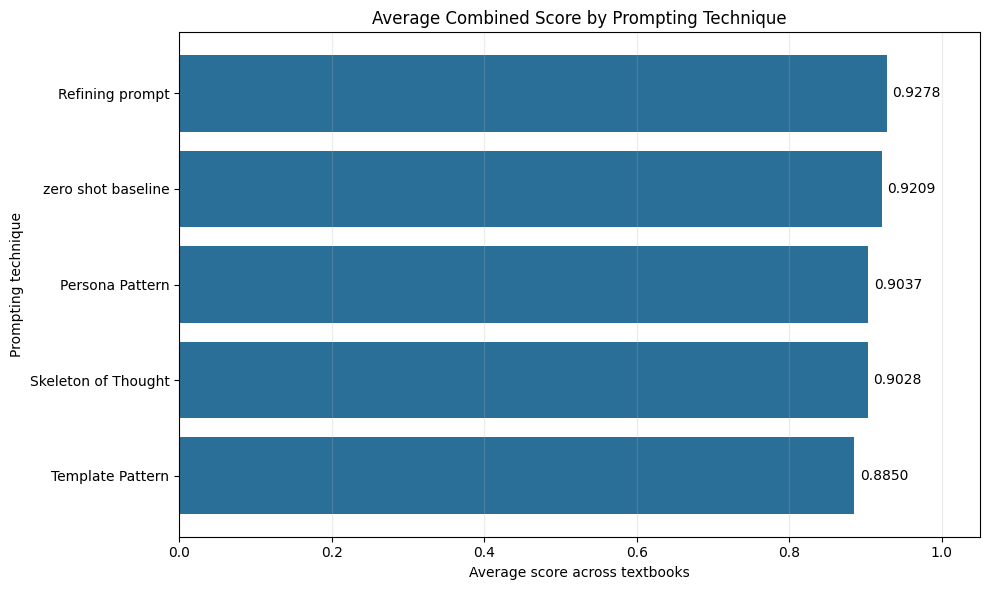

Saved graph to results/results_1_average_scores.png


In [6]:
average_plot_scores = average_scores.sort_values()



average_figure, average_axis = plt.subplots(figsize=(10, 6))

average_bars = average_axis.barh(

    average_plot_scores.index.str.replace("_", " "),

    average_plot_scores.values,

    color="#2A6F97",

)

average_axis.bar_label(average_bars, fmt="%.4f", padding=4)

average_axis.set_title("Average Combined Score by Prompting Technique")

average_axis.set_xlabel("Average score across textbooks")

average_axis.set_ylabel("Prompting technique")

average_axis.set_xlim(0, 1.05)

average_axis.grid(axis="x", alpha=0.25)

average_figure.tight_layout()



average_output_file = results_file.with_name(

    f"{results_file.stem}_average_scores.png"

)

average_figure.savefig(average_output_file, dpi=200)

plt.show()



print(f"Saved graph to {average_output_file}")

## Plot and Save the Graph



Render a horizontal bar chart and save a high-resolution PNG in the `results` directory.

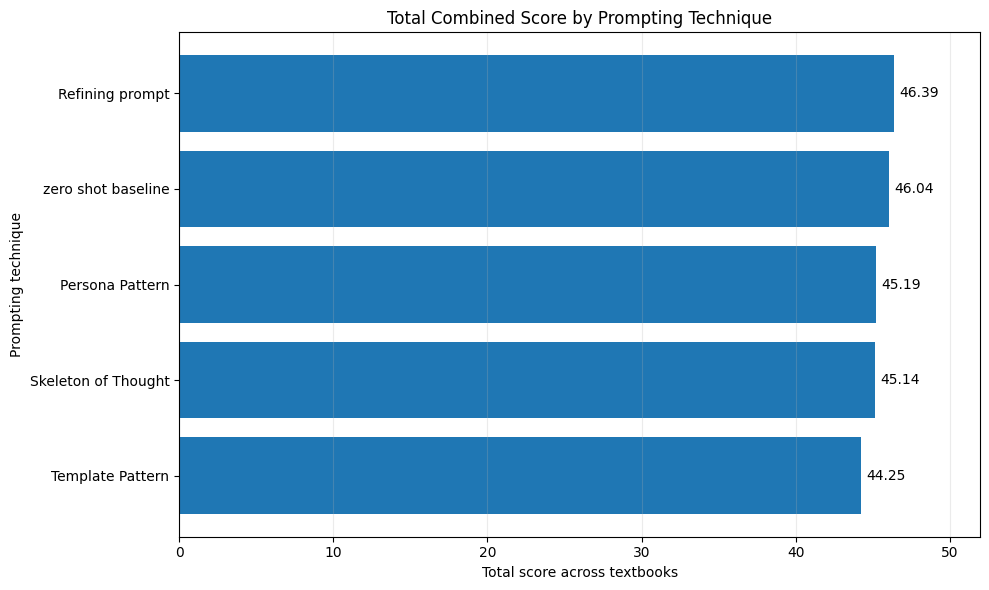

Saved graph to results/results_1_total_scores.png


In [4]:
figure, axis = plt.subplots(figsize=(10, 6))

bars = axis.barh(total_scores.index.str.replace("_", " "), total_scores.values)

axis.bar_label(bars, fmt="%.2f", padding=4)

axis.set_title("Total Combined Score by Prompting Technique")

axis.set_xlabel("Total score across textbooks")

axis.set_ylabel("Prompting technique")

axis.set_xlim(0, total_scores.max() * 1.12)

axis.grid(axis="x", alpha=0.25)

figure.tight_layout()



output_file = results_file.with_name(f"{results_file.stem}_total_scores.png")

figure.savefig(output_file, dpi=200)

plt.show()

print(f"Saved graph to {output_file}")